In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("ml-latest-small/ratings.csv")
df = df.drop(columns=["timestamp"])

# Create a user-item rating matrix
ratings_matrix = df.pivot(index="userId", columns="movieId", values="rating").fillna(0)

In [15]:
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances

def similarity_matrix(ratings, metric, user_based=True):
    if not user_based:
        ratings = ratings.T  # switch for item-based

    if metric == "cosine":
        return cosine_similarity(ratings.fillna(0))
    
    elif metric == "adjusted_cosine":
        if user_based:
            user_means = ratings.mean(axis=1)
            centered = ratings.sub(user_means, axis=0)
        else:
            item_means = ratings.mean(axis=0)
            centered = ratings.sub(item_means, axis=1)
        return cosine_similarity(centered.fillna(0))
    
    elif metric == "pearson":
        return 1 - pairwise_distances(ratings.fillna(0), metric="correlation")
    
    elif metric == "jaccard":
        binarized = (ratings >= 4).fillna(0).astype(int)
        return 1 - pairwise_distances(binarized.values, metric="jaccard")
    
    else:
        raise ValueError("Unsupported similarity metric")

In [ ]:
import numpy as np

def predict_user_based(ratings, sim_matrix, k=20):
    mean_user_rating = ratings.mean(axis=1).values.reshape(-1, 1)
    ratings_diff = (ratings - mean_user_rating).fillna(0)

    sim_sorted = np.argsort(-sim_matrix, axis=1)
    top_k_indices = np.array([row[:k] for row in sim_sorted])

    pred = np.zeros_like(ratings)

    for i in range(ratings.shape[0]):
        sim_scores = sim_matrix[i, top_k_indices[i]]
        neighbor_ratings = ratings_diff.values[top_k_indices[i]]
        weighted_sum = np.dot(sim_scores, neighbor_ratings)
        normalization = np.abs(sim_scores).sum()
        pred[i] = mean_user_rating[i] + (weighted_sum / normalization if normalization != 0 else 0)

    return pd.DataFrame(pred, index=ratings.index, columns=ratings.columns)

# Item-based prediction with item mean-centering
def predict_item_based_mean_centered(ratings, sim_matrix, k=20):
    # Prepare data
    mean_item_rating = ratings.mean(axis=0)
    ratings_values = ratings.values
    mean_item_values = mean_item_rating.values
    
    num_users, num_items = ratings_values.shape
    pred = np.zeros((num_users, num_items))
    
    # Get top-k similar items for each item (index-based)
    sim_sorted = np.argsort(-sim_matrix, axis=1)
    top_k_indices = np.array([row[:k] for row in sim_sorted])
    
    for i_idx in range(num_items):
        neighbors = top_k_indices[i_idx]
        sim_scores = sim_matrix[i_idx, neighbors]
        neighbor_items = neighbors

        for u_idx in range(num_users):
            user_ratings = ratings_values[u_idx, neighbor_items]
            rated_mask = user_ratings > 0

            if not np.any(rated_mask):
                pred[u_idx, i_idx] = mean_item_values[i_idx]
                continue

            relevant_sims = sim_scores[rated_mask]
            relevant_ratings = user_ratings[rated_mask] - mean_item_values[neighbor_items][rated_mask]

            weighted_sum = np.dot(relevant_sims, relevant_ratings)
            normalization = np.abs(relevant_sims).sum()

            pred[u_idx, i_idx] = mean_item_values[i_idx] + (weighted_sum / normalization if normalization != 0 else 0)

    return pd.DataFrame(pred, index=ratings.index, columns=ratings.columns)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(pred, true_ratings):
    true_values = true_ratings.values.flatten()
    pred_values = pred.values.flatten()
    
    mask = true_values > 0
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mean_squared_error(true_values[mask], pred_values[mask]))
    return mae, rmse

In [18]:
results = []

for user_based in [True, False]:
    for metric in ["cosine", "adjusted_cosine", "pearson", "jaccard"]:
        print(f"Evaluating {metric} similarity with {'user-based' if user_based else 'item-based'} collaborative filtering")
        sim = similarity_matrix(ratings_matrix, metric, user_based=user_based)
        for k in [5, 10, 20, 50]:
            print(f"  k={k}")
            if user_based:
                pred = predict_user_based(ratings_matrix, sim, k=k)
            else:
                pred = predict_item_based_mean_centered(ratings_matrix, sim, k=k)
            mae, rmse = evaluate(pred, ratings_matrix)
            results.append({
                "type": "User-Based" if user_based else "Item-Based",
                "metric": metric,
                "k": k,
                "MAE": mae,
                "RMSE": rmse
            })

Evaluating cosine similarity with user-based collaborative filtering
  k=5
  k=10
  k=20
  k=50
Evaluating adjusted_cosine similarity with user-based collaborative filtering
  k=5
  k=10
  k=20
  k=50
Evaluating pearson similarity with user-based collaborative filtering
  k=5
  k=10
  k=20
  k=50
Evaluating jaccard similarity with user-based collaborative filtering


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


  k=5
  k=10
  k=20
  k=50
Evaluating cosine similarity with item-based collaborative filtering
  k=5
  k=10
  k=20
  k=50
Evaluating adjusted_cosine similarity with item-based collaborative filtering
  k=5
  k=10
  k=20
  k=50
Evaluating pearson similarity with item-based collaborative filtering
  k=5
  k=10
  k=20
  k=50
Evaluating jaccard similarity with item-based collaborative filtering


c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


  k=5
  k=10
  k=20
  k=50


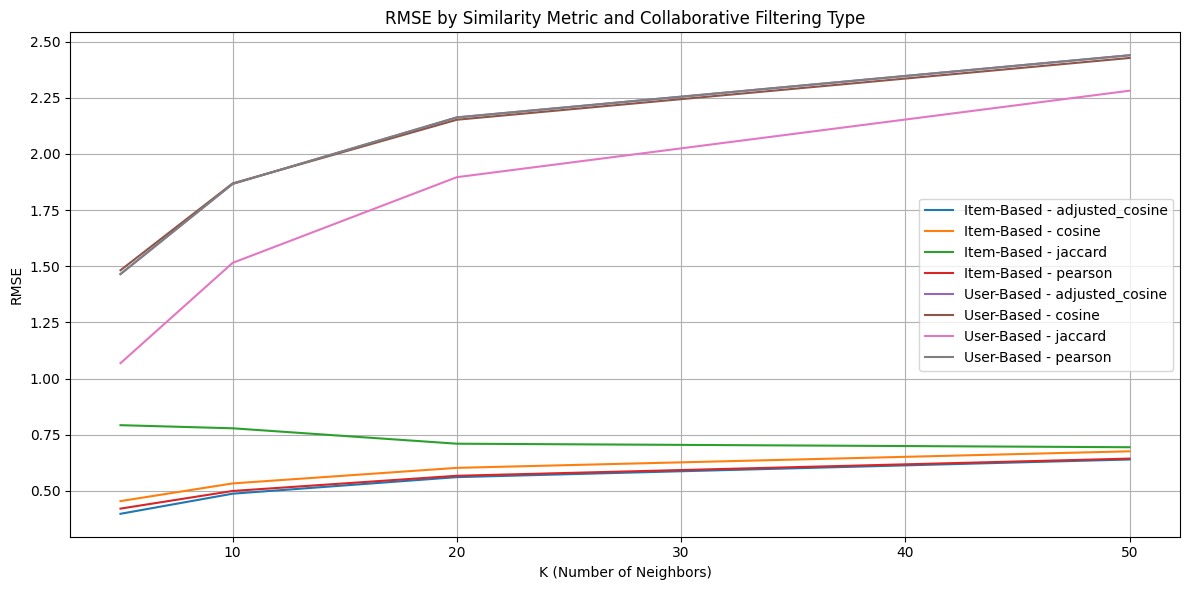

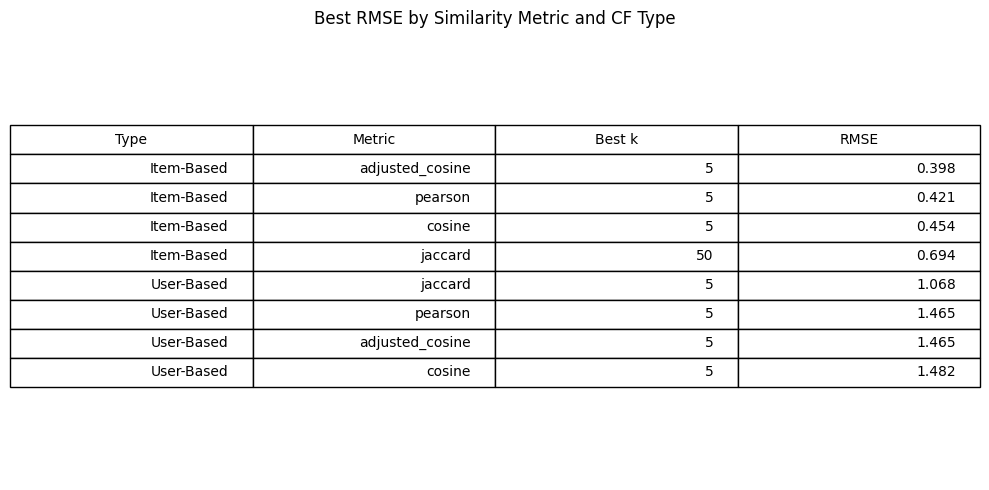

In [20]:
import matplotlib.pyplot as plt

# Group results for plotting
results_df = pd.DataFrame(results)
grouped = results_df.groupby(["type", "metric"])

# Plot
plt.figure(figsize=(12, 6))
for (filter_type, metric), group in grouped:
    plt.plot(group["k"], group["RMSE"], label=f"{filter_type} - {metric}")

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("RMSE")
plt.title("RMSE by Similarity Metric and Collaborative Filtering Type")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import matplotlib.table as tbl

# Summarize by averaging RMSE per metric and CF type at best k
summary = results_df.loc[results_df.groupby(['type', 'metric'])['RMSE'].idxmin()]
summary = summary.sort_values(by=["type", "RMSE"])

# Create a separate figure for the table
fig, ax = plt.subplots(figsize=(10, len(summary) * 0.5 + 1))
ax.axis('off')
table_data = summary[["type", "metric", "k", "RMSE"]].round(3).values.tolist()
column_labels = ["Type", "Metric", "Best k", "RMSE"]
table = ax.table(cellText=table_data, colLabels=column_labels, loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.title("Best RMSE by Similarity Metric and CF Type")
plt.tight_layout()
plt.show()